In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Types of analysis in EDA**
## **Univariable | Bivariable | Multivariable**
### -> No of features:
*   Single feature analysis -> Univariable Analysis
*   Two feature analysis -> Bivariable Analysis
*   More than two feature analysis -> Multivariable Analysis






In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/cleaned_customer_sales.csv')

In [13]:
df.dtypes

,0
Customer_ID,object
Name,object
Gender,object
Age,int64
City,object
Signup_Date,object
Last_Purchase_Date,object
Purchase_Amount,float64
Feedback_Score,float64
Email,object


In [15]:
# changing date columns to datetime
df['Signup_Date'] = pd.to_datetime(df ['Signup_Date'])
df['Last_Purchase_Date'] = pd. to_datetime(df ['Last_Purchase_Date'])

In [18]:
df.dtypes

,0
Customer_ID,object
Name,object
Gender,object
Age,int64
City,object
Signup_Date,datetime64[ns]
Last_Purchase_Date,datetime64[ns]
Purchase_Amount,float64
Feedback_Score,float64
Email,object


### **Univariate Analysis**

In [24]:
df.describe()

,Age,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score
count,1550.000000,1550,1550,1550.000000,1523.000000
mean,34.375484,2024-07-13 06:01:23.612902912,2025-07-12 02:12:51.096774400,102.180413,3.923835
min,18.000000,2022-07-22 00:00:00,2022-08-15 00:00:00,5.000000,1.000000
25%,26.000000,2023-08-01 06:00:00,2024-12-28 00:00:00,37.860000,3.000000
50%,34.000000,2024-07-24 12:00:00,2025-10-14 00:00:00,68.600000,4.000000
75%,42.000000,2025-07-14 00:00:00,2026-04-06 00:00:00,123.632500,5.000000
max,68.000000,2026-06-21 00:00:00,2026-07-22 00:00:00,2137.640000,5.000000
std,10.979101,NaN,NaN,117.241514,1.089661


In [27]:
# summary statistics for numerical column
numeric_cols = ['Age', 'Purchase_Amount', 'Feedback_Score']
summary = df[numeric_cols].describe().T
summary['median'] = df[numeric_cols].median()
summary['IQR'] = summary['75%'] - summary['25%']
summary['skewness'] = df[numeric_cols].skew()
print("Numeric Summary Statistics:\n")
summary

Numeric Summary Statistics:



,count,mean,std,min,25%,50%,75%,max,median,IQR,skewness
Age,1550.0,34.375484,10.979101,18.0,26.00,34.0,42.0000,68.00,34.0,16.0000,0.383480
Purchase_Amount,1550.0,102.180413,117.241514,5.0,37.86,68.6,123.6325,2137.64,68.6,85.7725,5.769690
Feedback_Score,1523.0,3.923835,1.089661,1.0,3.00,4.0,5.0000,5.00,4.0,2.0000,-0.937855


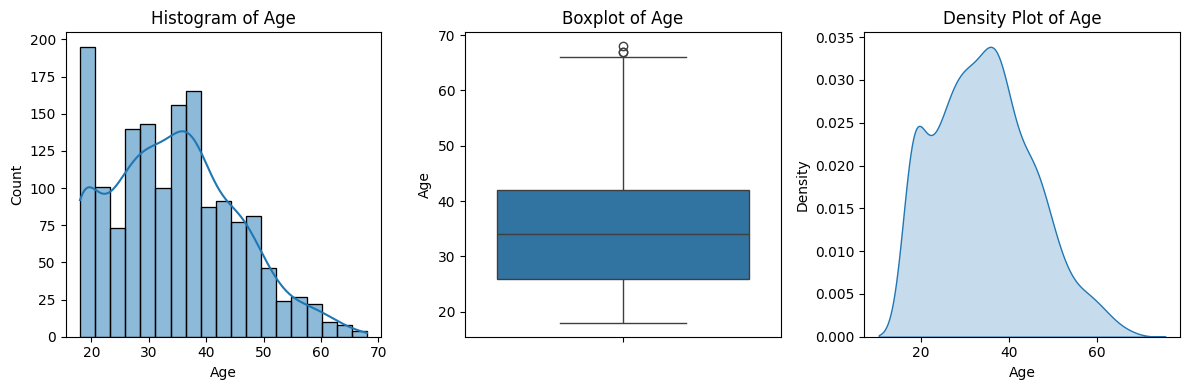

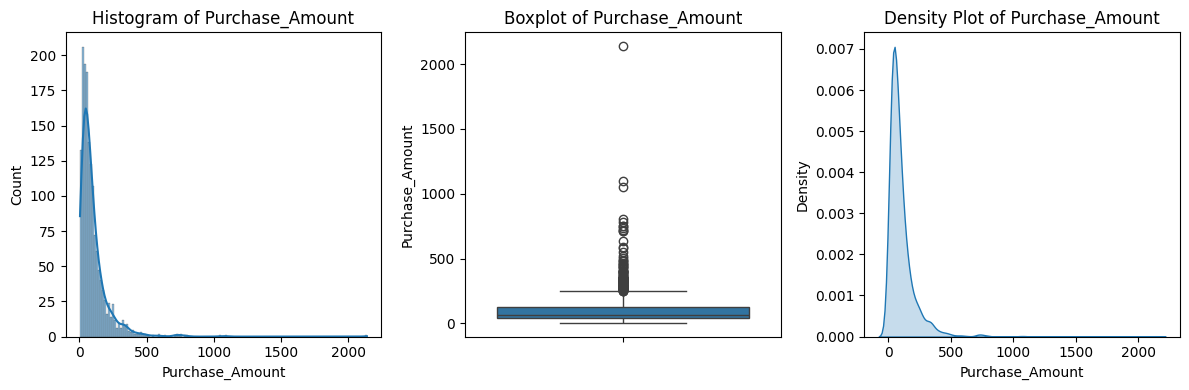

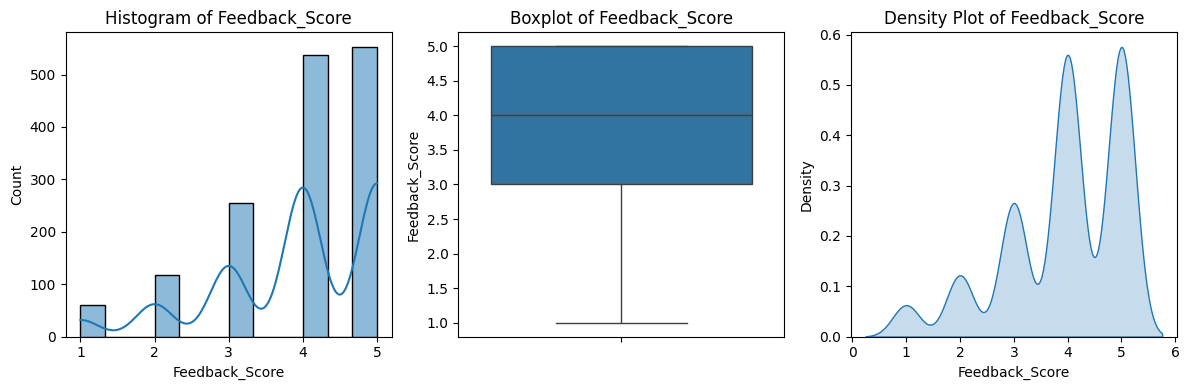

In [32]:
# histogram, boxplot, density plot for numerical columns
for col in numeric_cols:
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1,3,2)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

    plt.subplot(1,3,3)
    sns.kdeplot(df[col], fill=True)
    plt.title(f'Density Plot of {col}')

    plt.tight_layout()
    plt.show()


 Frequency counts for Gender:
 Gender
Male      747
Female    736
Other      67
Name: count, dtype: int64


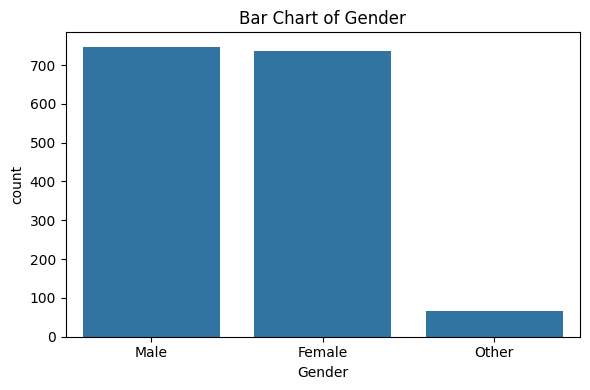


 Frequency counts for City:
 City
Rawalpindi     93
Manchester     85
Houston        84
Faisalabad     83
Gujranwala     82
Dubai          82
Los Angeles    81
Sydney         81
Singapore      80
Chicago        77
London         77
Toronto        75
New York       73
Lahore         71
Sialkot        69
Islamabad      69
Karachi        69
Quetta         69
Multan         68
Peshawar       67
Name: count, dtype: int64


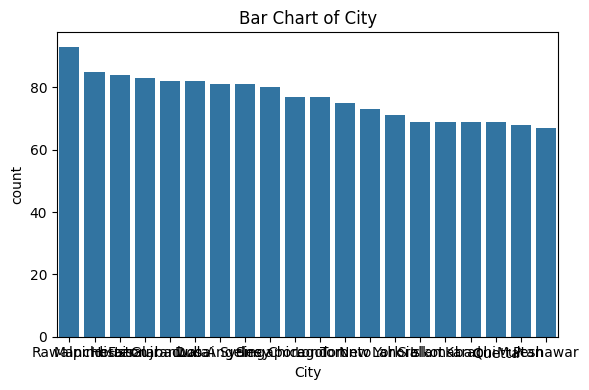

In [34]:
# Frequency count for categorical columns
cat_cols = ['Gender', 'City']

for index, col in enumerate(cat_cols):
  print(f"\n Frequency counts for {col}:\n", df[col].value_counts())
  plt.figure(figsize=(6,4))
  sns.countplot(x=col, data=df, order=df [col].value_counts(). index)
  plt.title(f'Bar Chart of {col}')
  plt.tight_layout()
  plt.show()


 Date Range for Signup_Date: 2022-07-22 00:00:00 to 2026-06-21 00:00:00
Time span: 1430 days

 Date Range for Last_Purchase_Date: 2022-08-15 00:00:00 to 2026-07-22 00:00:00
Time span: 1437 days


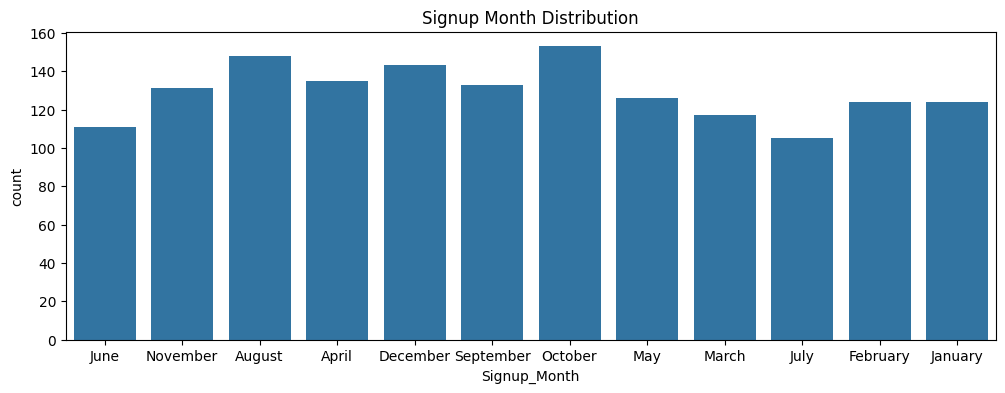

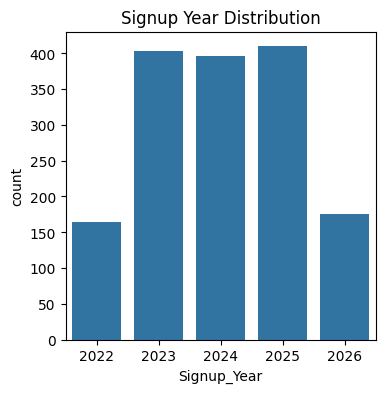

In [37]:
date_cols = ['Signup_Date', 'Last_Purchase_Date']

for col in date_cols:
  print(f"\n Date Range for {col}: {df[col].min()} to {df[col].max()}")
  print(f"Time span: {(df[col].max() - df[col].min()).days} days")

# Month distribution
plt.figure(figsize = (12,4))
df ['Signup_Month'] = df['Signup_Date'].dt.month_name()
sns. countplot (x='Signup_Month', data=df)
plt.title('Signup Month Distribution')
plt.show()

# Year distribution

plt.figure(figsize = (4,4))
df['Signup_Year'] = df['Signup_Date'].dt. year
sns. countplot (x='Signup_Year', data=df)
plt.title('Signup Year Distribution')
plt.show()

In [39]:
def time_granularity(series):
  diffs = series.sort_values().diff().dropna().dt.days
  return diffs.describe()

In [40]:
time_granularity(df['Last_Purchase_Date'])

,Last_Purchase_Date
count,1549.000000
mean,0.927695
std,2.091558
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,51.000000


In [41]:
df['Last_Purchase_Date'].sort_values()

,Last_Purchase_Date
1116,2022-08-15
1185,2022-10-05
1206,2022-10-13
27,2022-10-14
1057,2022-10-27
...,...
1179,2026-07-21
975,2026-07-22
662,2026-07-22
1168,2026-07-22


In [47]:
df['Last_Purchase_Date'].sort_values().diff().value_counts()

,count
Last_Purchase_Date,
0 days,782
1 days,532
2 days,118
3 days,39
5 days,21
4 days,18
6 days,14
8 days,11
7 days,4


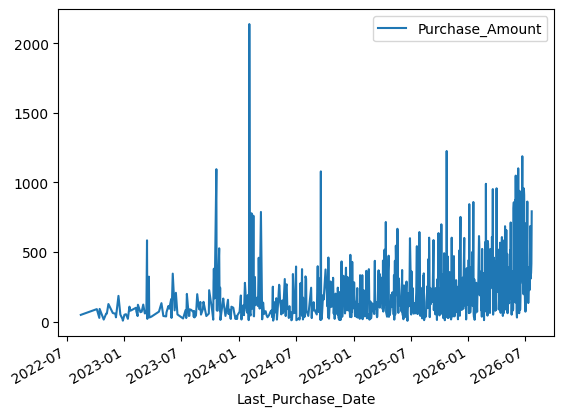

In [48]:
df.groupby('Last_Purchase_Date') [ ['Purchase_Amount']].sum() . plot()
plt.show()

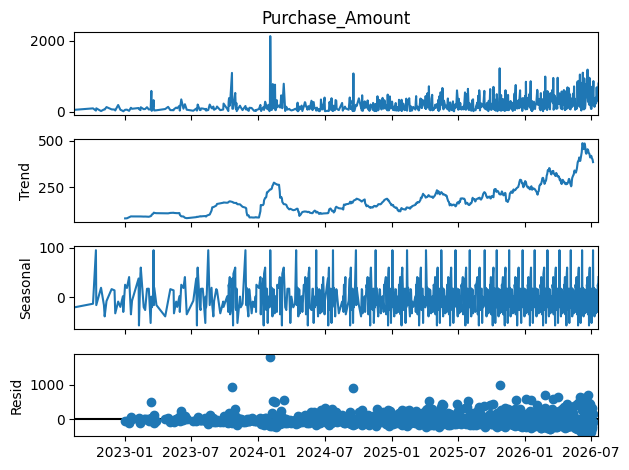

In [49]:
from statsmodels. tsa. seasonal import seasonal_decompose

df_daily = df.groupby('Last_Purchase_Date') ['Purchase_Amount'].sum()
result = seasonal_decompose(df_daily, model='additiye', period=30)
result.plot().show()

In [51]:
df["day"] = df["Last_Purchase_Date"].dt.day
df["month"] = df["Last_Purchase_Date"].dt.month
heatmap_data = df.pivot_table(
index="day",
columns="month",
values="Purchase_Amount",
aggfunc="mean"
)
heatmap_data


month,1,2,3,4,5,6,7,8,9,10,11,12
day,,,,,,,,,,,,
1,103.415000,71.790000,102.675000,123.792500,97.480000,371.060000,142.550000,41.910000,NaN,45.280000,48.120000,101.080000
2,90.785000,91.328571,104.298333,76.263333,127.325000,79.793333,47.526667,106.468333,146.765000,29.770000,200.293333,121.144000
3,64.728000,1143.240000,43.800000,51.623333,49.073333,50.185714,68.915000,55.253333,62.825000,125.106667,72.876667,71.646667
4,183.436000,123.006000,148.465714,130.610000,145.710000,109.712500,91.860000,111.910000,NaN,173.340000,92.120000,82.017143
5,120.335000,109.030000,139.517500,73.988750,106.883750,43.375000,115.592500,81.345000,85.383333,111.696667,64.732500,63.100000
6,53.016667,47.740000,153.455000,100.696667,46.950000,69.696667,76.520000,90.420000,49.617500,72.415000,58.200000,195.496667
7,127.105000,96.930000,70.396000,66.235000,112.662500,134.014286,77.359000,23.930000,50.333333,174.875000,16.040000,301.120000
8,58.550000,63.098750,93.971429,80.508333,72.852500,86.132000,137.952500,NaN,121.990000,61.730000,63.093333,77.440000
9,49.375000,158.795000,120.804000,134.676000,101.408750,154.228750,69.050000,51.733333,90.922500,83.540000,201.160000,56.865000


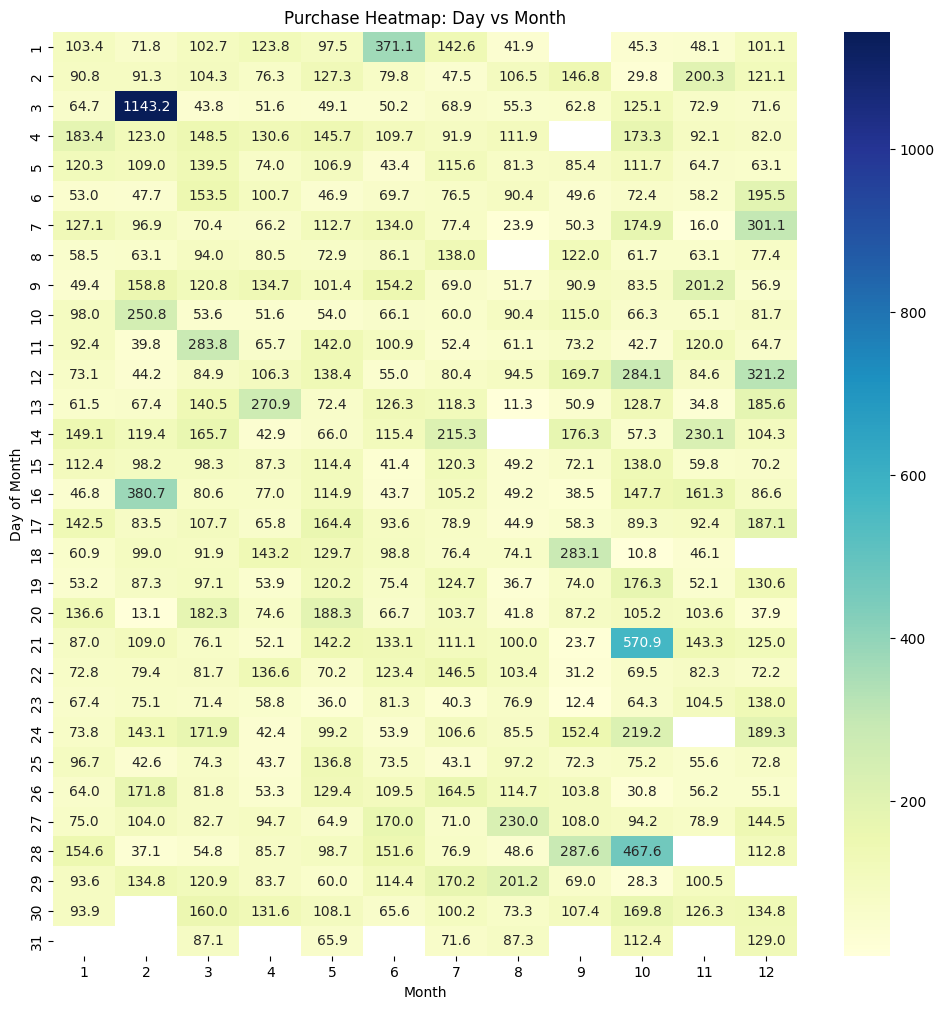

In [52]:
# Plot heatmap
plt.figure(figsize=(12,12))
sns.heatmap(heatmap_data, cmap='YlGnBu', annot=True, fmt=".1f")
plt.xlabel("Month")
plt.ylabel("Day of Month")
plt.title("Purchase Heatmap: Day vs Month")
plt.show()

In [54]:
text_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/fake_or_real_news_1000.csv')
text_df

,title,text,label
0,Technology: Shocking Claim #1 Goes Viral,A viral social media post claims an extraordin...,FAKE
1,Politics: Shocking Claim #2 Goes Viral,A viral social media post claims an extraordin...,FAKE
2,Sports: Shocking Claim #3 Goes Viral,A viral social media post claims an extraordin...,FAKE
3,Business: Shocking Claim #4 Goes Viral,A viral social media post claims an extraordin...,FAKE
4,Business: Shocking Claim #5 Goes Viral,A viral social media post claims an extraordin...,FAKE
...,...,...,...
995,Science: Official Update #496,According to official statements and multiple ...,REAL
996,Education: Official Update #497,According to official statements and multiple ...,REAL
997,World: Official Update #498,According to official statements and multiple ...,REAL
998,Sports: Official Update #499,According to official statements and multiple ...,REAL


In [57]:
# Text preprocessing
import re
def clean_text(text):
  text = text. lower()
  text = re.sub(r"[^a-z\s]", "", text)
  return text

text_df["clean_text"] = text_df["text"].apply(clean_text)

In [58]:
text_df

,title,text,label,clean_text
0,Technology: Shocking Claim #1 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...
1,Politics: Shocking Claim #2 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...
2,Sports: Shocking Claim #3 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...
3,Business: Shocking Claim #4 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...
4,Business: Shocking Claim #5 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...
...,...,...,...,...
995,Science: Official Update #496,According to official statements and multiple ...,REAL,according to official statements and multiple ...
996,Education: Official Update #497,According to official statements and multiple ...,REAL,according to official statements and multiple ...
997,World: Official Update #498,According to official statements and multiple ...,REAL,according to official statements and multiple ...
998,Sports: Official Update #499,According to official statements and multiple ...,REAL,according to official statements and multiple ...


In [59]:
text_df["tokens"] = text_df["clean_text"].apply(lambda x: x.split())

In [60]:
text_df

,title,text,label,clean_text,tokens
0,Technology: Shocking Claim #1 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...,"[a, viral, social, media, post, claims, an, ex..."
1,Politics: Shocking Claim #2 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...,"[a, viral, social, media, post, claims, an, ex..."
2,Sports: Shocking Claim #3 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...,"[a, viral, social, media, post, claims, an, ex..."
3,Business: Shocking Claim #4 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...,"[a, viral, social, media, post, claims, an, ex..."
4,Business: Shocking Claim #5 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...,"[a, viral, social, media, post, claims, an, ex..."
...,...,...,...,...,...
995,Science: Official Update #496,According to official statements and multiple ...,REAL,according to official statements and multiple ...,"[according, to, official, statements, and, mul..."
996,Education: Official Update #497,According to official statements and multiple ...,REAL,according to official statements and multiple ...,"[according, to, official, statements, and, mul..."
997,World: Official Update #498,According to official statements and multiple ...,REAL,according to official statements and multiple ...,"[according, to, official, statements, and, mul..."
998,Sports: Official Update #499,According to official statements and multiple ...,REAL,according to official statements and multiple ...,"[according, to, official, statements, and, mul..."


In [62]:
text_df["token_count"] = text_df["tokens"].apply( len)
text_df

,title,text,label,clean_text,tokens,token_count
0,Technology: Shocking Claim #1 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...,"[a, viral, social, media, post, claims, an, ex...",37
1,Politics: Shocking Claim #2 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...,"[a, viral, social, media, post, claims, an, ex...",37
2,Sports: Shocking Claim #3 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...,"[a, viral, social, media, post, claims, an, ex...",37
3,Business: Shocking Claim #4 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...,"[a, viral, social, media, post, claims, an, ex...",37
4,Business: Shocking Claim #5 Goes Viral,A viral social media post claims an extraordin...,FAKE,a viral social media post claims an extraordin...,"[a, viral, social, media, post, claims, an, ex...",37
...,...,...,...,...,...,...
995,Science: Official Update #496,According to official statements and multiple ...,REAL,according to official statements and multiple ...,"[according, to, official, statements, and, mul...",30
996,Education: Official Update #497,According to official statements and multiple ...,REAL,according to official statements and multiple ...,"[according, to, official, statements, and, mul...",30
997,World: Official Update #498,According to official statements and multiple ...,REAL,according to official statements and multiple ...,"[according, to, official, statements, and, mul...",30
998,Sports: Official Update #499,According to official statements and multiple ...,REAL,according to official statements and multiple ...,"[according, to, official, statements, and, mul...",30


Token Count Summary
count    1000.000000
mean       33.500000
std         3.501751
min        30.000000
25%        30.000000
50%        33.500000
75%        37.000000
max        37.000000
Name: token_count, dtype: float64


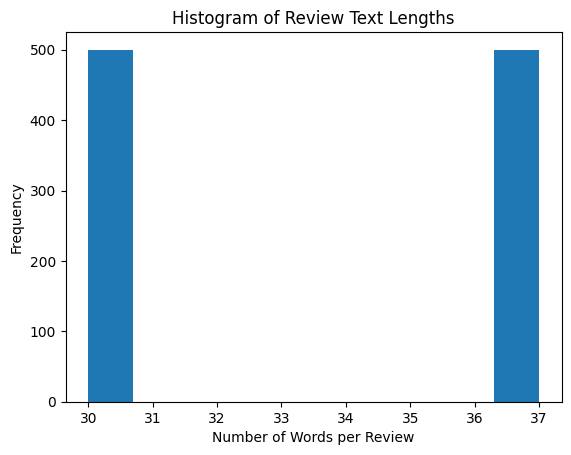

In [63]:
print("Token Count Summary")
print(text_df["token_count"].describe())

# Histogram of text lengths
plt.figure()
plt.hist(text_df["token_count"])
plt.xlabel("Number of Words per Review")
plt.ylabel("Frequency")
plt.title("Histogram of Review Text Lengths")
plt.show()

In [66]:
from collections import Counter

# Most common words
all_tokens = [token for tokens in text_df["tokens"] for token in tokens]
word_freq = Counter(all_tokens)

top_words = word_freq.most_common(10)
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])

print("\nTop 10 Most Common Words")  # Make sure this has proper closing )
print(top_words_df)  # This line is actually fine


Top 10 Most Common Words
       word  count
0        to   1500
1       the   1500
2       and   1500
3         a   1000
4    claims   1000
5   article   1000
6   sources   1000
7  provides   1000
8  language   1000
9     viral    500


In [68]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True


Top 10 Most Common Words
            word  count
0         claims   1000
1        article   1000
2        sources   1000
3       provides   1000
4       language   1000
5          viral    500
6         social    500
7          media    500
8           post    500
9  extraordinary    500


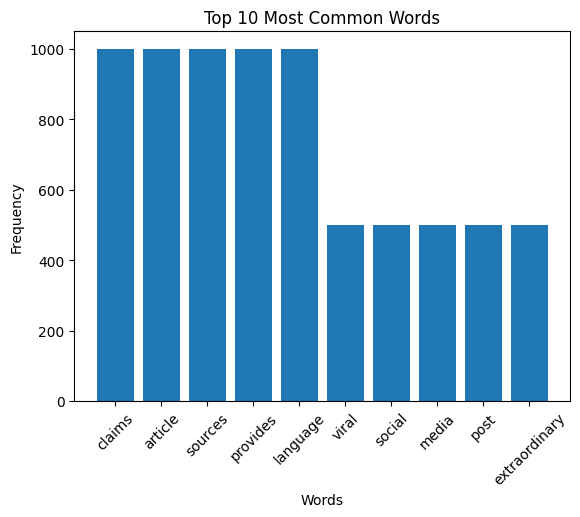

In [69]:
import nltk
from nltk.corpus import stopwords
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Ensure the stopwords resource is available
nltk.download('stopwords', quiet=True)  # 'quiet=True' suppresses the download logs

# Your existing code
stopword = set(stopwords.words('english'))  # It's good practice to specify 'english' or your target language
all_tokens = [token for token in all_tokens if token not in stopword]
word_freq = Counter(all_tokens)

top_words = word_freq.most_common(10)
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])

print("\nTop 10 Most Common Words")
print(top_words_df)

plt.figure()
plt.bar(top_words_df["word"], top_words_df["count"])
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Most Common Words")
plt.xticks(rotation=45)
plt.show()

### **Bivariate Analysis**

In [71]:
weather_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/weather.csv')
weather_df

,temp,atemp,hum,windspeed(mph),windspeed(ms),cnt
0,9.591402,13.727171,86.9479,6.073929,2.006151,553
1,0.375161,18.489310,54.9155,13.741765,10.261066,1529
2,4.125440,5.266805,42.4685,21.773493,3.813179,1331
3,3.348161,12.535933,57.0812,11.811855,3.174406,3041
4,11.047068,13.426125,88.3692,20.380113,8.452439,2314
...,...,...,...,...,...,...
726,10.084224,6.559648,43.3970,14.808728,5.487992,1556
727,4.042665,15.559237,94.3087,6.805148,10.610318,776
728,0.603475,5.439862,78.4498,9.652467,10.782404,2067
729,11.344032,8.425535,65.0476,9.376179,4.813886,3095


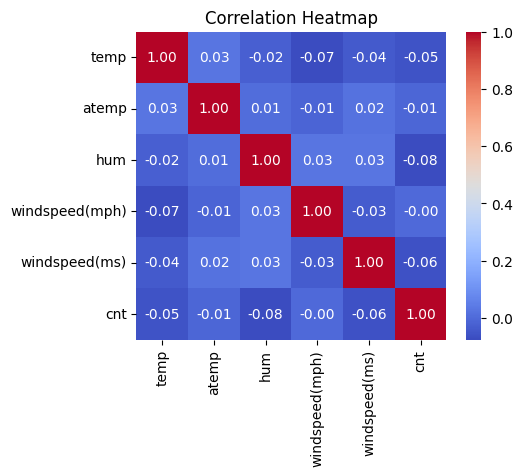

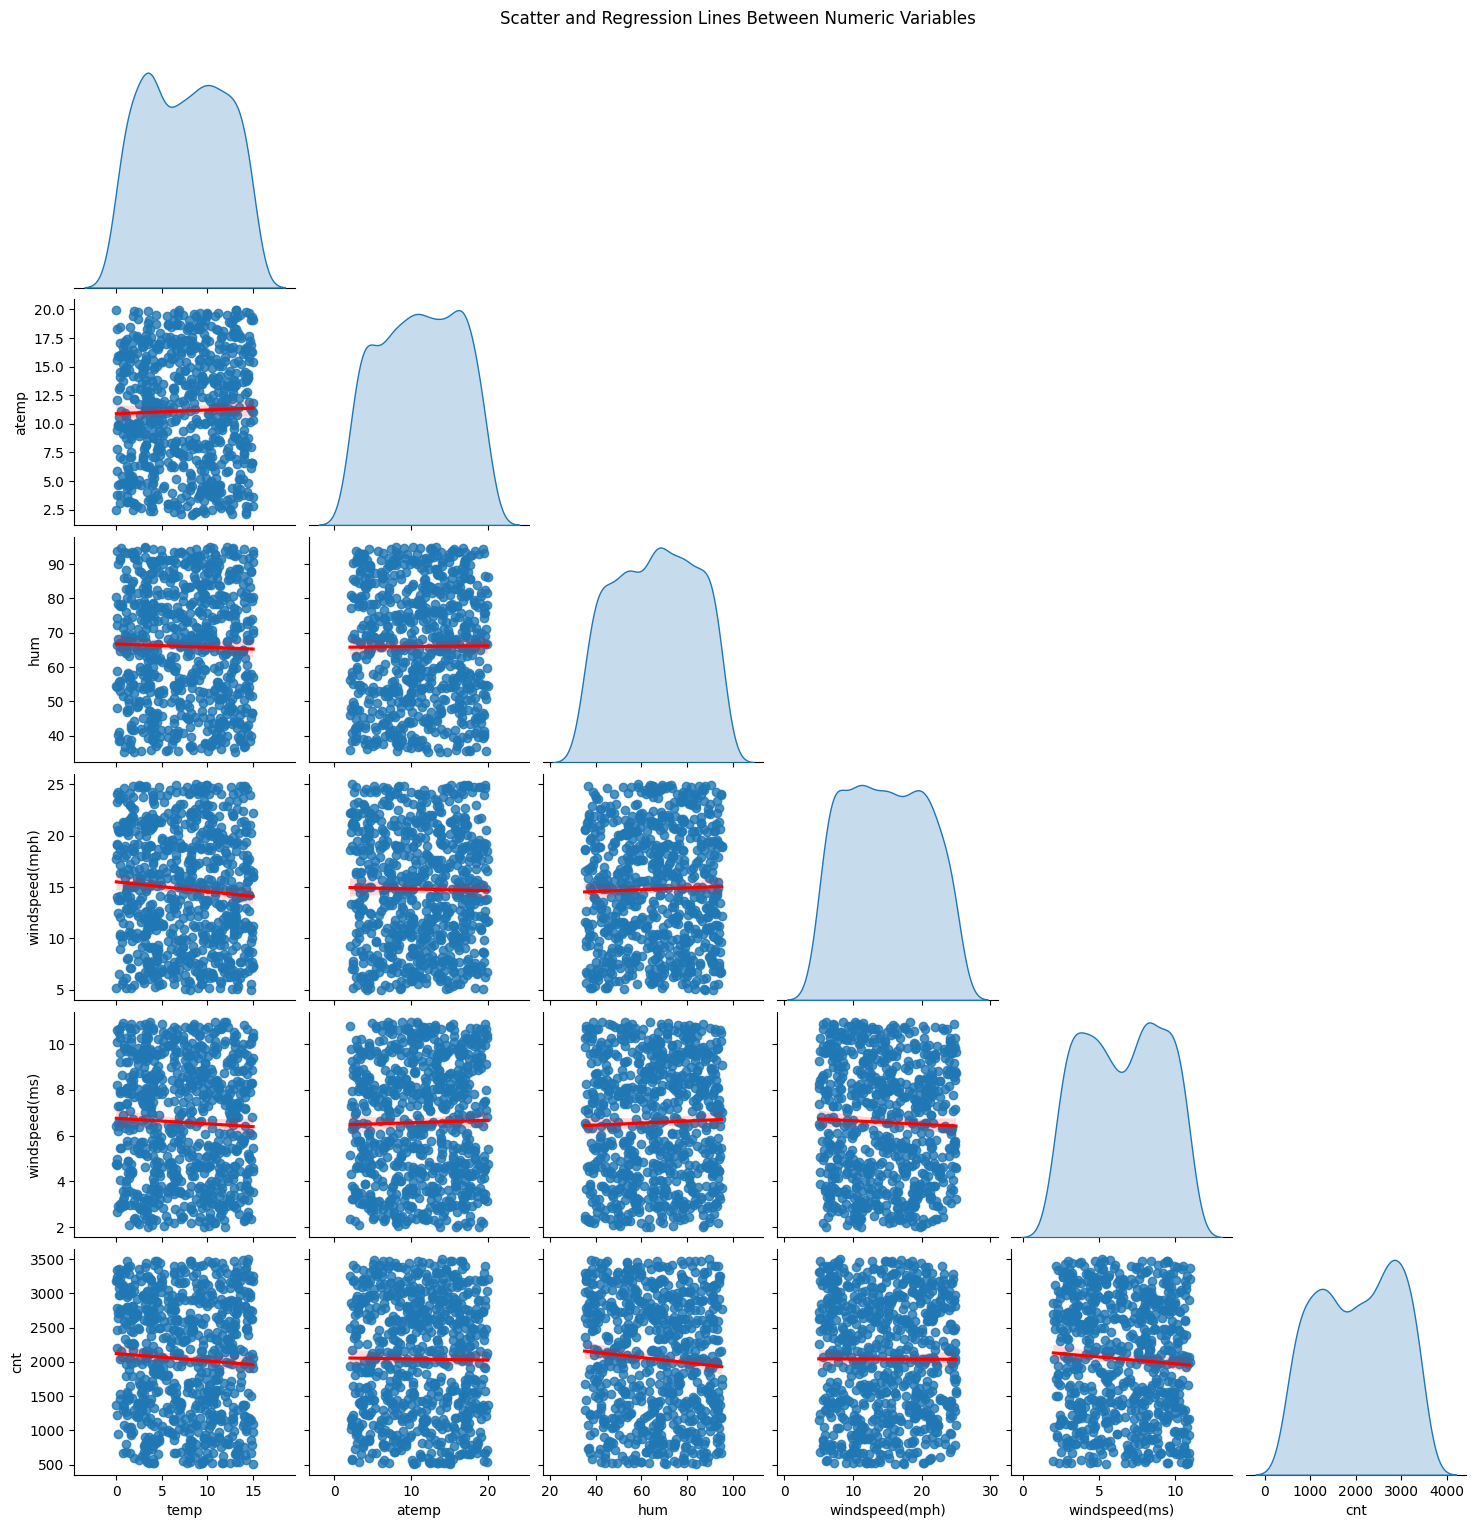

In [73]:
corr = weather_df.corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Pairwise scatter plots + regression line
sns.pairplot(weather_df, kind='reg', diag_kind='kde', corner=True, plot_kws={'line_kws':{'color':'red'}})
plt.suptitle('Scatter and Regression Lines Between Numeric Variables', y=1.02)
plt.show()

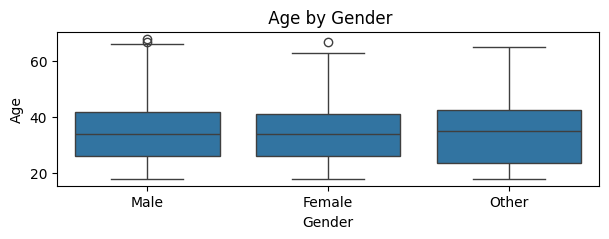


 Group Mean and Median of Age by Gender:
             mean  median  count
Gender                          
Female  34.122283    34.0    736
Male    34.607764    34.0    747
Other   34.567164    35.0     67


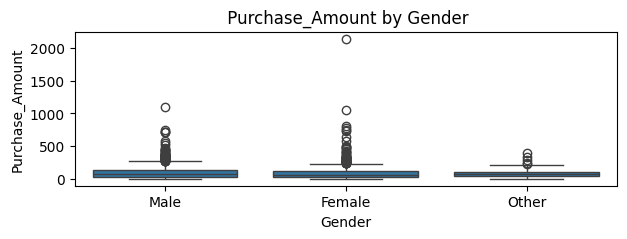


 Group Mean and Median of Purchase_Amount by Gender:
              mean  median  count
Gender                           
Female   99.542514   66.60    736
Male    105.529665   70.44    747
Other    93.816269   74.29     67


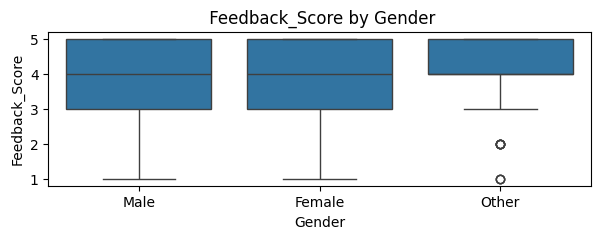


 Group Mean and Median of Feedback_Score by Gender:
            mean  median  count
Gender                         
Female  3.875519     4.0    723
Male    3.957766     4.0    734
Other   4.075758     4.0     66


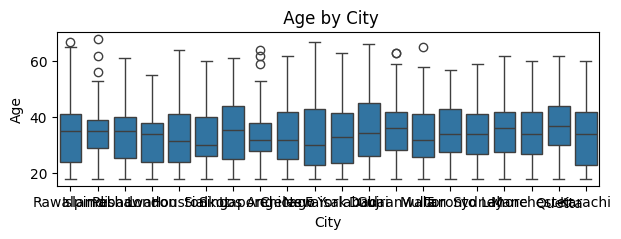


 Group Mean and Median of Age by City:
                  mean  median  count
City                                 
Chicago      33.844156    32.0     77
Dubai        34.926829    34.5     82
Faisalabad   33.072289    33.0     83
Gujranwala   36.048780    36.0     82
Houston      33.750000    31.5     84
Islamabad    35.057971    35.0     69
Karachi      34.028986    34.0     69
Lahore       35.746479    36.0     71
London       32.701299    34.0     77
Los Angeles  33.765432    32.0     81
Manchester   33.905882    34.0     85
Multan       33.691176    32.0     68
New York     32.917808    30.0     73
Peshawar     34.716418    35.0     67
Quetta       37.637681    37.0     69
Rawalpindi   34.333333    35.0     93
Sialkot      33.579710    30.0     69
Singapore    34.862500    35.5     80
Sydney       34.666667    34.0     81
Toronto      34.600000    34.0     75


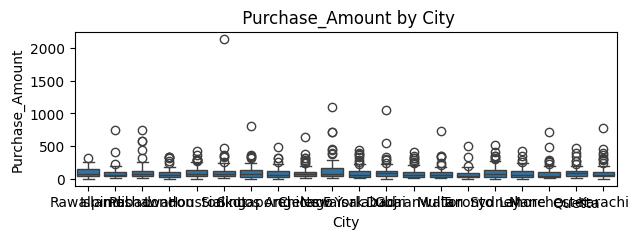


 Group Mean and Median of Purchase_Amount by City:
                   mean  median  count
City                                  
Chicago      102.114935  80.650     77
Dubai        109.860610  85.365     82
Faisalabad   100.656145  65.250     83
Gujranwala    94.722317  64.875     82
Houston      107.488571  72.725     84
Islamabad     94.630435  66.360     69
Karachi      107.440145  64.650     69
Lahore        90.195211  64.500     71
London        87.385844  64.780     77
Los Angeles   89.411358  66.560     81
Manchester    88.709176  48.980     85
Multan        90.424265  59.765     68
New York     142.587534  79.060     73
Peshawar     119.520000  77.700     67
Quetta       103.809565  90.420     69
Rawalpindi   100.543763  75.870     93
Sialkot      132.870000  73.690     69
Singapore    107.225125  80.990     80
Sydney       110.464074  79.590     81
Toronto       72.760800  51.980     75


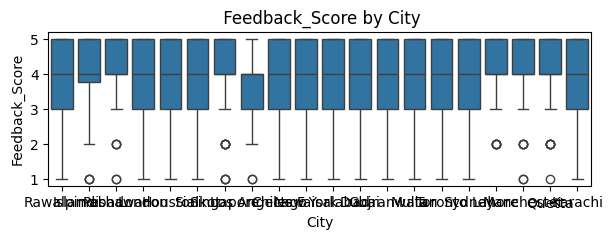


 Group Mean and Median of Feedback_Score by City:
                 mean  median  count
City                                
Chicago      3.786667     4.0     75
Dubai        3.876543     4.0     81
Faisalabad   3.804878     4.0     82
Gujranwala   3.812500     4.0     80
Houston      3.903614     4.0     83
Islamabad    4.088235     4.0     68
Karachi      3.880597     4.0     67
Lahore       4.128571     4.0     70
London       3.918919     4.0     74
Los Angeles  3.725000     4.0     80
Manchester   4.060976     4.0     82
Multan       3.835821     4.0     67
New York     3.736111     4.0     72
Peshawar     4.092308     4.0     65
Quetta       4.014706     4.0     68
Rawalpindi   4.000000     4.0     93
Sialkot      3.971014     4.0     69
Singapore    4.103896     4.0     77
Sydney       3.913580     4.0     81
Toronto      3.864865     4.0     74


In [76]:
cat_cols = ['Gender', 'City']

for cat in cat_cols:
  for num in numeric_cols:
    plt.figure(figsize=(7,2))
    sns. boxplot(x=cat, y=num, data=df)
    plt.title(f' {num} by {cat}')
    plt.show()

    print(f"\n Group Mean and Median of {num} by {cat}:")
    print(df.groupby(cat) [num].agg( ['mean', 'median', 'count']))

In [77]:
from scipy import stats
anova_res = stats.f_oneway(*[group ["Feedback_Score"]. values for name, group in df.groupby("City")])
print(" ANOVA Test for Feedback_Score across Cities:")
print("F-statistic:", round(anova_res.statistic, 3), ", p-value:", round(anova_res.pvalue, 3))

 ANOVA Test for Feedback_Score across Cities:
F-statistic: nan , p-value: nan



 Contingency Table (Gender vs City):
 City    Chicago  Dubai  Faisalabad  Gujranwala  Houston  Islamabad  Karachi  \
Gender                                                                        
Female       33     38          35          41       43         31       31   
Male         42     40          44          40       36         37       32   
Other         2      4           4           1        5          1        6   

City    Lahore  London  Los Angeles  Manchester  Multan  New York  Peshawar  \
Gender                                                                        
Female      37      28           39          43      40        36        36   
Male        32      43           40          39      24        36        29   
Other        2       6            2           3       4         1         2   

City    Quetta  Rawalpindi  Sialkot  Singapore  Sydney  Toronto  
Gender                                                           
Female      35          41       32  

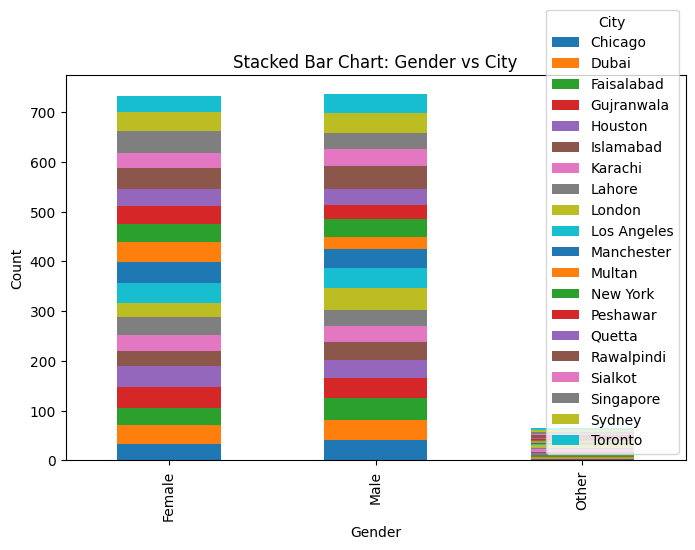


Chi-Square Test Results:
Chi2 = 29.173, p-value = 0.847, Degrees of Freedom = 38
 No significant relationship (fail to reject null hypothesis)


In [82]:
contingency = pd.crosstab(df['Gender'], df['City'])
print("\n Contingency Table (Gender vs City):\n", contingency)

# Stacked Bar Chart
contingency.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title('Stacked Bar Chart: Gender vs City')
plt.ylabel('Count')
plt.show()

# Chi-Square Test of Independence
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print("\nChi-Square Test Results:")
print(f"Chi2 = {chi2:.3f}, p-value = {p:.3f}, Degrees of Freedom = {dof}")

if p < 0.05:
  print(" Significant relationship (reject null hypothesis)")
else:
  print(" No significant relationship (fail to reject null hypothesis)")

In [85]:
sales = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/daily_sales_data.csv')
sales

,date,sales
0,2024-01-02,2226
1,2024-01-03,1517
2,2024-01-04,2517
3,2024-01-05,1097
4,2024-01-07,1196
...,...,...
95,2024-04-22,2501
96,2024-04-23,2933
97,2024-04-24,1230
98,2024-04-25,1581


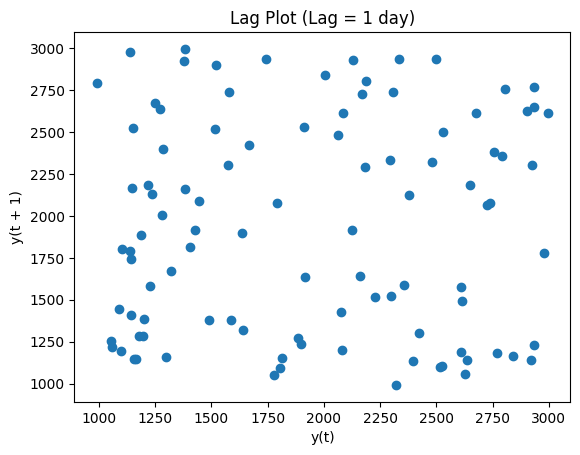

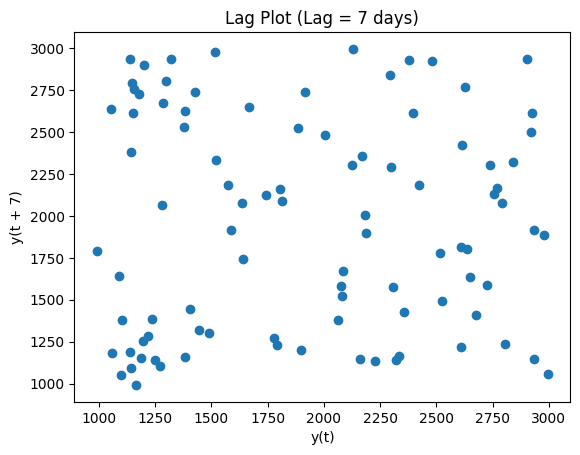

In [86]:
from pandas.plotting import lag_plot

plt. figure()
lag_plot(sales["sales"], lag=1)
plt.title("Lag Plot (Lag = 1 day)")
plt.show()

plt.figure()
lag_plot(sales["sales"], lag=7)
plt.title("Lag Plot (Lag = 7 days)")
plt.show()

<Figure size 640x480 with 0 Axes>

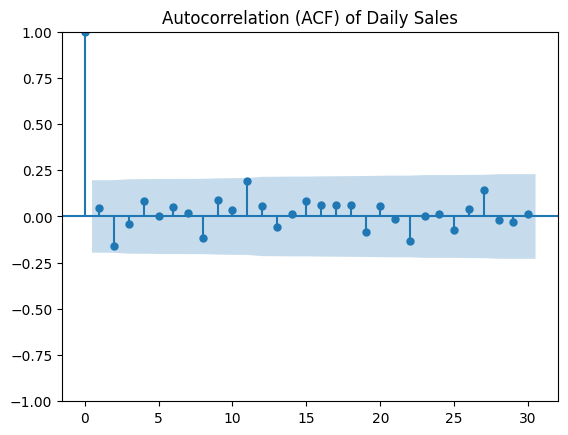

In [87]:
from statsmodels.graphics.tsaplots import plot_acf

plt.figure()
plot_acf(sales["sales"], lags=30)
plt.title("Autocorrelation (ACF) of Daily Sales")
plt.show()

<Figure size 640x480 with 0 Axes>

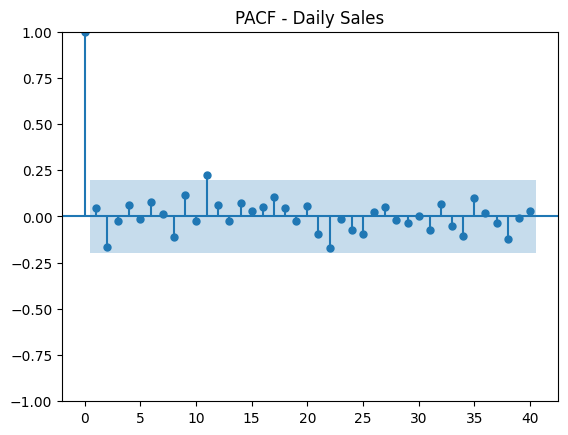

In [88]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure()
plot_pacf(sales["sales"], lags=40, method="ywm")
plt.title("PACF - Daily Sales")
plt.show()

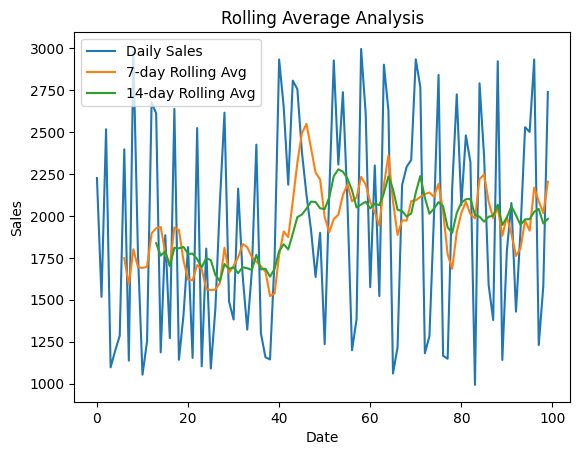

In [89]:
sales["rolling_7"] = sales["sales"].rolling(window=7).mean()
sales["rolling_14"] = sales["sales"].rolling(window=14) .mean()

plt.figure()
plt.plot(sales.index, sales["sales"], label="Daily Sales")
plt.plot(sales.index, sales["rolling_7"], label="7-day Rolling Avg")
plt.plot(sales.index, sales["rolling_14"], label="14-day Rolling Avg")
plt.xlabel("Date")
plt.ylabel("Sales")
plt. title("Rolling Average Analysis")
plt. legend()
plt.show()

### **Multivariate Analysis**

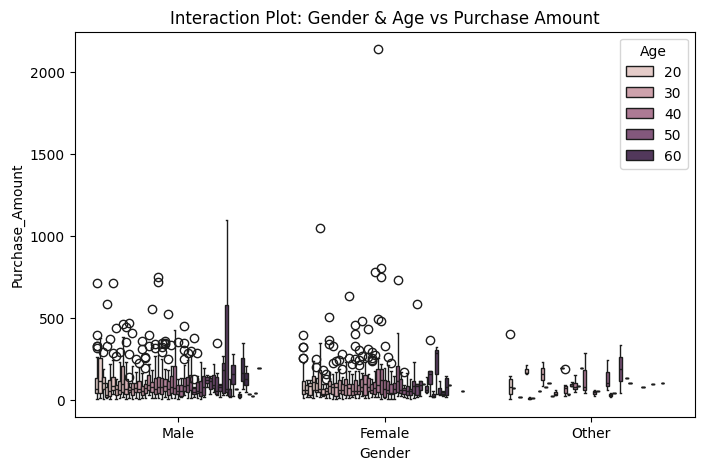

In [93]:
# Example: Age + Gender - Purchase Amount
plt.figure(figsize=(8,5))
sns.boxplot(
  data=df,
  x='Gender',
  y='Purchase_Amount',
  hue='Age',
  dodge=True
)
plt.title('Interaction Plot: Gender & Age vs Purchase Amount')
plt.show()

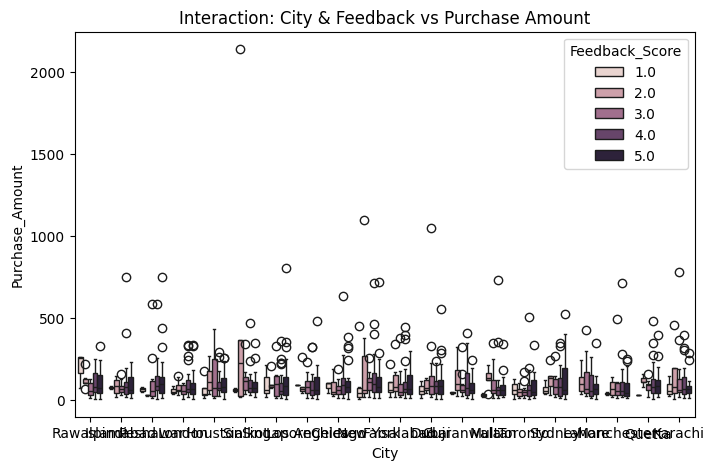

In [95]:
# Another example: City + Feedback + Purchase Amount


plt.figure(figsize=(8,5))
sns. boxplot(
data=df,
x='City',
y='Purchase_Amount',
hue='Feedback_Score'
)
plt.title('Interaction: City & Feedback vs Purchase Amount')
plt.show()

In [97]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer  # Add this import

# Select numerical columns
X = df[numeric_cols]

# Handle missing values: replace NaN with the mean of each column
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.34488339 0.33522428]


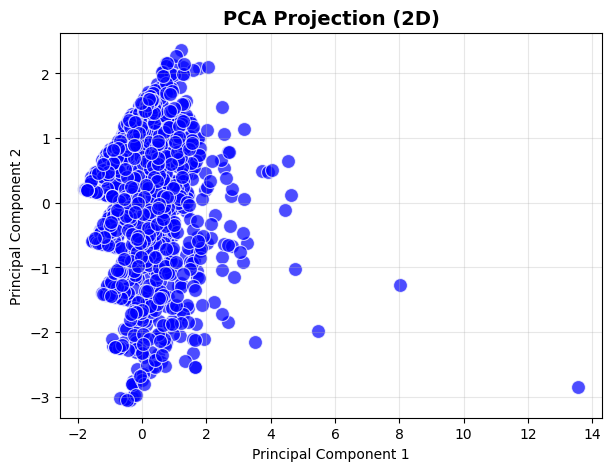

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    data=df,
    s=100,  # Size of points
    alpha=0.7,  # Transparency (optional)
    color='blue'  # Color (optional)
)

plt.title('PCA Projection (2D)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True, alpha=0.3)
plt.show()

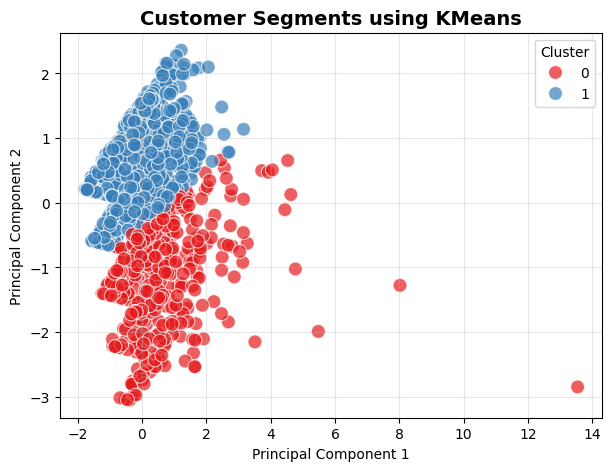

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_pca)  # Fixed spacing: 'fit_predict' not 'fit_predict'

plt.figure(figsize=(7,5))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100,  # Lowercase 's'
    alpha=0.7  # Optional: add transparency
)
plt.title('Customer Segments using KMeans', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [103]:
df['Cluster'].value_counts()

,count
Cluster,
1,1057
0,493


In [105]:
print(df.groupby('Cluster')[numeric_cols].mean())

               Age  Purchase_Amount  Feedback_Score
Cluster                                            
0        32.598377       139.998256        2.664622
1        35.204352        84.541627        4.519342
